# Diabetes Healthcare Analytics - End-to-End Project

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose             

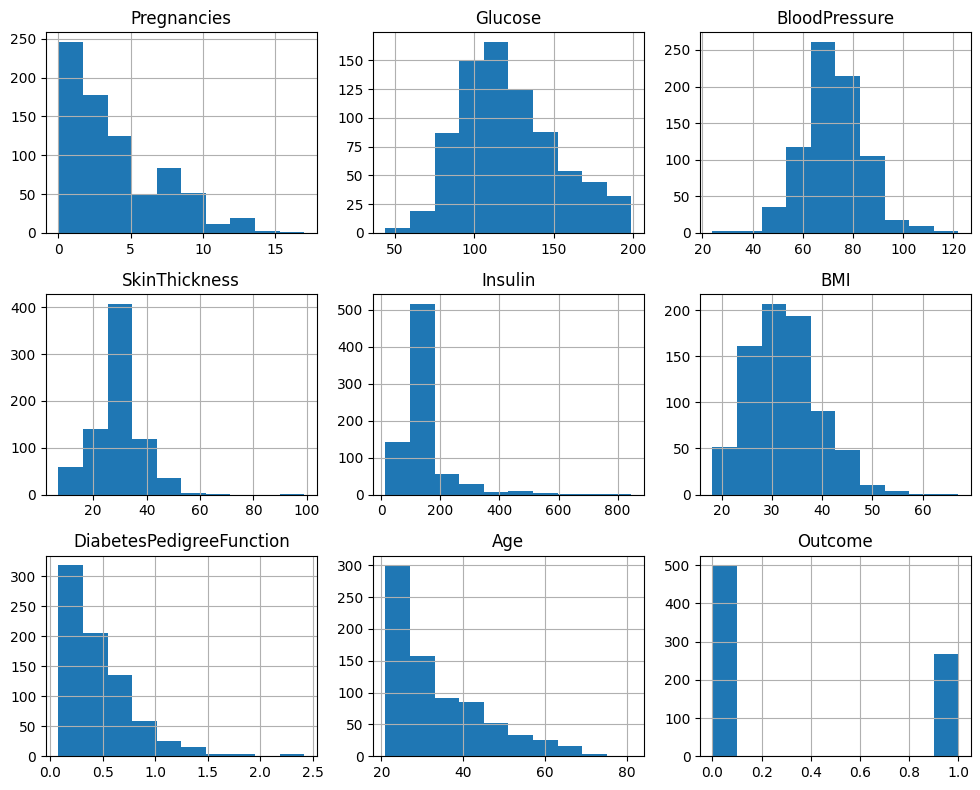

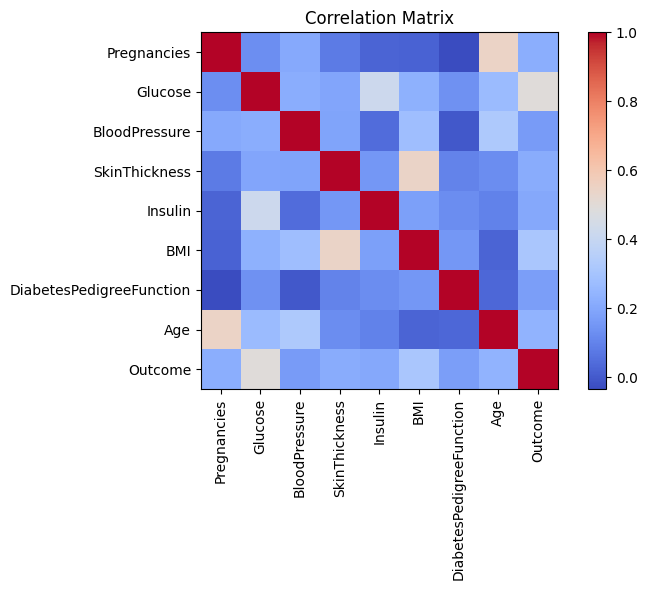


Logistic Regression
Accuracy: 0.7078
Cross Validation: 0.7722
ROC AUC: 0.813

Confusion Matrix
[[82 18]
 [27 27]]

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


Decision Tree
Accuracy: 0.6818
Cross Validation: 0.7111
ROC AUC: 0.6357

Confusion Matrix
[[79 21]
 [28 26]]

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154


Random Forest
Accuracy: 0.7792
Cross Validation: 0.7644
ROC AUC: 0.8192

C

In [7]:
"""
Diabetes Healthcare Analytics - End-to-End Project
-------------------------------------------------
This template combines the major stages of a diabetes analytics project:
1. Load data
2. Explore data
3. Clean data
4. Visualize
5. Train ML models
6. Evaluate models
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# -----------------------------
# Load Dataset
# -----------------------------
col_names = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv("diabetes_dataset.csv", names=col_names)
print(df.head())

print(df.shape)
print(df.info())
print(df.describe())

# -----------------------------
# Data Cleaning
# -----------------------------
cols_with_invalid_zero = [
    "Glucose","BloodPressure","SkinThickness","Insulin","BMI"
]

for col in cols_with_invalid_zero:
    if col in df.columns:
        df[col] = df[col].replace(0, np.nan)
        df[col] = df[col].fillna(df[col].median())

print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------
# Exploratory Data Analysis
# -----------------------------
print("\nOutcome Distribution")
print(df["Outcome"].value_counts())

df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# -----------------------------
# Prepare Data
# -----------------------------
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, proba)
    else:
        auc = None

    acc = accuracy_score(y_test, pred)
    cv = cross_val_score(model, X, y, cv=5).mean()

    results.append((name, acc, cv, auc))

    print("\n==============================")
    print(name)
    print("==============================")
    print("Accuracy:", round(acc,4))
    print("Cross Validation:", round(cv,4))
    if auc is not None:
        print("ROC AUC:", round(auc,4))
    print("\nConfusion Matrix")
    print(confusion_matrix(y_test,pred))
    print("\nClassification Report")
    print(classification_report(y_test,pred))

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Cross Validation","ROC AUC"]
)

print("\nModel Comparison")
print(results_df.sort_values("Accuracy", ascending=False))

best = results_df.sort_values("Accuracy", ascending=False).iloc[0]
print("\nBest Model:")
print(best)
